# 03 — Train a TCOCNN and understand its predictions

One complete cycle from customer sub-sensor 0 enters the network and one gas concentration comes
out. This notebook uses one fixed architecture—there is no hyperparameter optimization yet.

In [1]:
from pathlib import Path
import sys,h5py,numpy as np,matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents) if (p/'Networks'/'TCOCNNv3.py').exists())
sys.path.insert(0,str(ROOT/'Networks'))
sys.path.insert(0,str(ROOT/'Evaluation Seminar'/'Day_03'))
from TCOCNNv3 import TCOCNNv3Class
from day3_utils import prepare_model_data,train_experiment,regression_metrics,plot_comparison,show_results
with h5py.File(ROOT/'Data'/'fullData.mat','r') as f:
    AVAILABLE_GASES=sorted(k for k in f['targets_train'] if k not in {'range','calibration'})
print('Available target gases:',AVAILABLE_GASES)
GAS='acetone'
splits,scaler=prepare_model_data(GAS)
print('Input:',splits['train']['X_z'].shape,'= Zyklen × 1 sub-sensor × 1440 × 1')
print('Output:',splits['train']['y_z'].shape,'= one concentration per cycle')


Available target gases: ['VOCsum', 'acetic_acid', 'acetone', 'carbon_monoxide', 'ethanol', 'ethyl_acetate', 'formaldehyde', 'hydrogen', 'isopropanol', 'toluene', 'water', 'xylene']
Input: (1090, 1, 1440, 1) = Zyklen × 1 sub-sensor × 1440 × 1
Output: (1090, 1) = one concentration per cycle


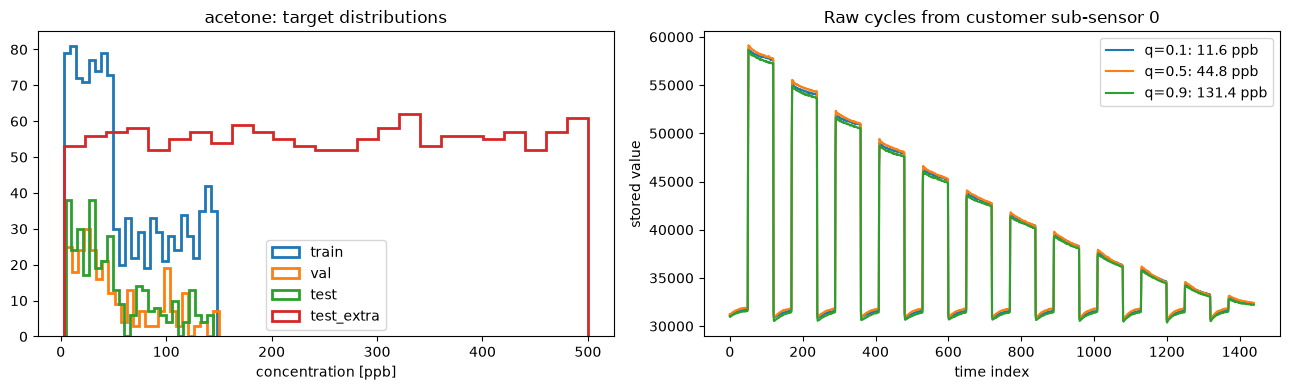

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for split_name, color in zip(
    ["train", "val", "test", "test_extra"],
    ["tab:blue", "tab:orange", "tab:green", "tab:red"],
):
    axes[0].hist(
        splits[split_name]["y"],
        bins=25,
        histtype="step",
        linewidth=2,
        color=color,
        label=split_name,
    )
axes[0].set(title=f"{GAS}: target distributions", xlabel="concentration [ppb]")
axes[0].legend()

train_targets = splits["train"]["y"]
for quantile in [0.1, 0.5, 0.9]:
    wanted = np.quantile(train_targets, quantile)
    index = int(np.argmin(np.abs(train_targets - wanted)))
    axes[1].plot(
        splits["train"]["X"][index, 0, :, 0],
        label=f"q={quantile:.1f}: {train_targets[index]:.1f} ppb",
    )
axes[1].set(
    title="Raw cycles from customer sub-sensor 0",
    xlabel="time index",
    ylabel="stored value",
)
axes[1].legend()
fig.tight_layout()

## Build the model visibly

The default parameters are written explicitly below. The real architecture and trainable parameter
count are printed before training.

In [3]:
PARAMS=dict(n_filter=24,section_depth=3,convs_per_block=3,channel_growth=16,kernel=9,stride=4,
 num_neurons=128,drop_out=0.0,initial_learning_rate=3e-4,residual=True,batch_size=64)
preview=TCOCNNv3Class(splits['train']['X_z'].shape[1:],1,regression=True)
preview.build_net(PARAMS)
print(preview.model)
print('Trainable parameters:',sum(p.numel() for p in preview.model.parameters() if p.requires_grad))
model,info=train_experiment(splits,PARAMS,epochs=40,seed=42,model_class=TCOCNNv3Class)


TCOCNNModule(
  (features): Sequential(
    (0): ResidualConvBlock(
      (convolutions): ModuleList(
        (0): SamePadConv2d(
          (conv): Conv2d(1, 24, kernel_size=(1, 9), stride=(1, 1))
        )
        (1-2): 2 x SamePadConv2d(
          (conv): Conv2d(24, 24, kernel_size=(1, 9), stride=(1, 1))
        )
      )
      (normalizations): ModuleList(
        (0-2): 3 x BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (projection): Sequential(
        (0): SamePadConv2d(
          (conv): Conv2d(1, 24, kernel_size=(1, 1), stride=(1, 1))
        )
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (activation): ReLU()
    )
    (1): MaxPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0, dilation=1, ceil_mode=True)
    (2): ResidualConvBlock(
      (convolutions): ModuleList(
        (0): SamePadConv2d(
          (conv): Conv2d(24, 40, kernel_size=(1, 9), s

## Learning curves

Training and validation MSE are shown on linear and logarithmic axes. The vertical line marks the
validation checkpoint restored for prediction.

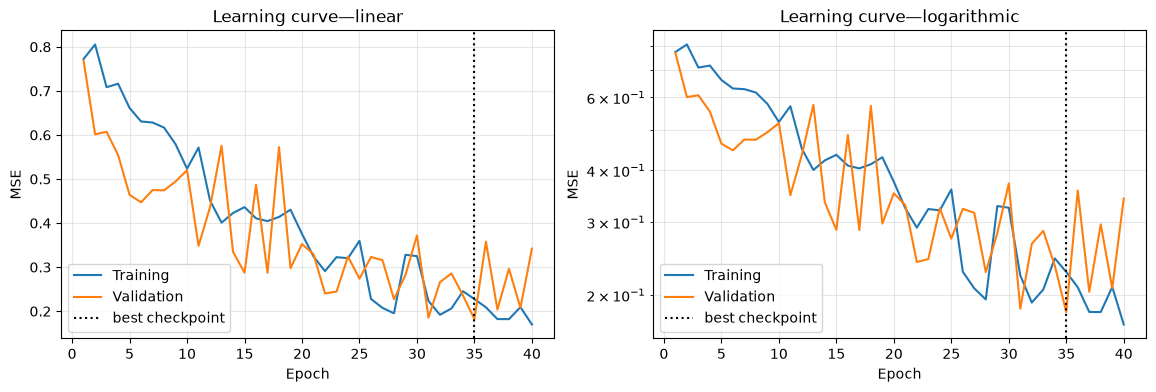

In [4]:
h=model.history.history; e=np.arange(1,len(h['loss'])+1)
fig,axes=plt.subplots(1,2,figsize=(14,4))
for ax in axes:
    ax.plot(e,h['loss'],label='Training'); ax.plot(e,h['val_loss'],label='Validation')
    ax.axvline(info['best_epoch'],color='black',ls=':',label='best checkpoint')
    ax.set(xlabel='Epoch',ylabel='MSE'); ax.grid(True,which='both',alpha=.3); ax.legend()
axes[0].set_title('Learning curve—linear')
axes[1].set(title='Learning curve—logarithmic',yscale='log')
plt.show()


## Output in ppb

Model outputs are transformed back to the physical unit. Parity and residual plots show validation,
regular test, and extrapolation-test behavior separately.

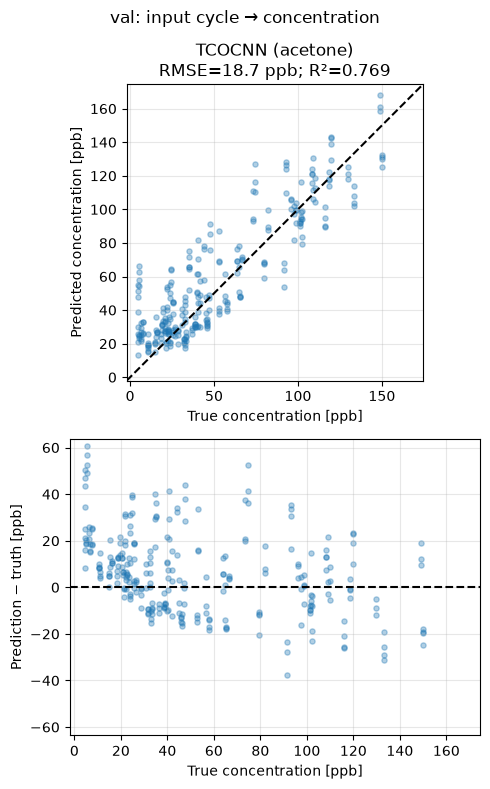

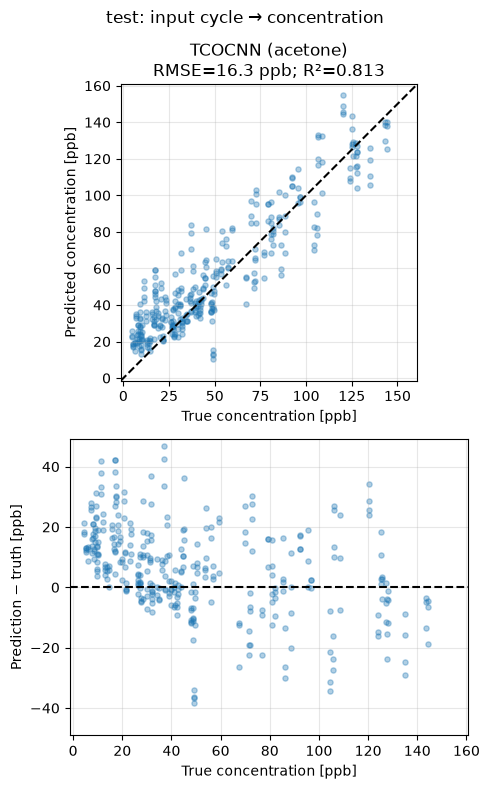

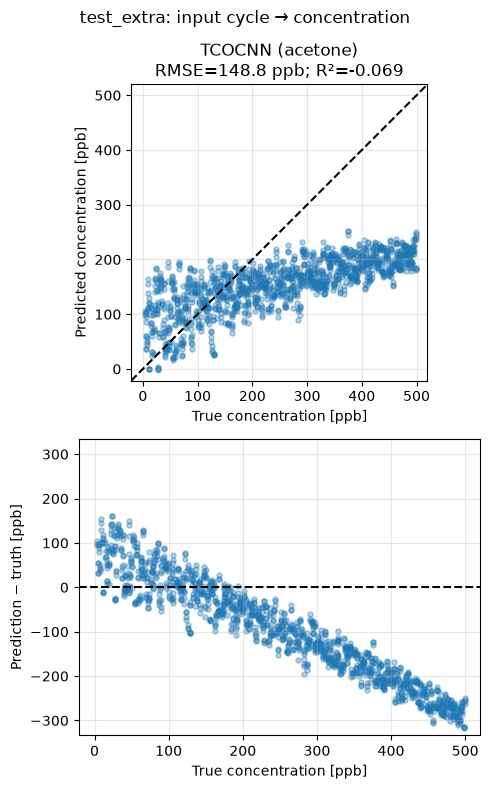

Split,RMSE_ppb,MAE_ppb,R2,bias_ppb
val,18.682,14.577,0.769,6.192
test,16.265,12.761,0.813,6.074
test_extra,148.799,121.428,-0.069,-97.385


In [5]:
rows=[]
for name in ['val','test','test_extra']:
    truth=splits[name]['y']
    pred=model.predict(splits[name]['X_z']).ravel()*scaler['y_std']+scaler['y_mean']
    rows.append({'Split':name,**regression_metrics(truth,pred)})
    plot_comparison(truth,{f'TCOCNN ({GAS})':pred},f'{name}: input cycle → concentration')
show_results(rows)
